# 02 — Feature: Company
Engineers a numeric feature from the `Company` column using target mean encoding.

**Output feature:** `Company_TE`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
ld = pd.read_csv("laptop_data_features.csv")
print(f"Shape: {ld.shape}")

Shape: (1303, 11)


In [3]:
# Explore Company
print(ld['Company'].value_counts())
print(f"\nUnique companies: {ld['Company'].nunique()}")

Company
Dell         297
Lenovo       297
HP           274
Asus         158
Acer         103
MSI           54
Toshiba       48
Apple         21
Samsung        9
Razer          7
Mediacom       7
Microsoft      6
Xiaomi         4
Vero           4
Chuwi          3
Google         3
Fujitsu        3
LG             3
Huawei         2
Name: count, dtype: int64

Unique companies: 19


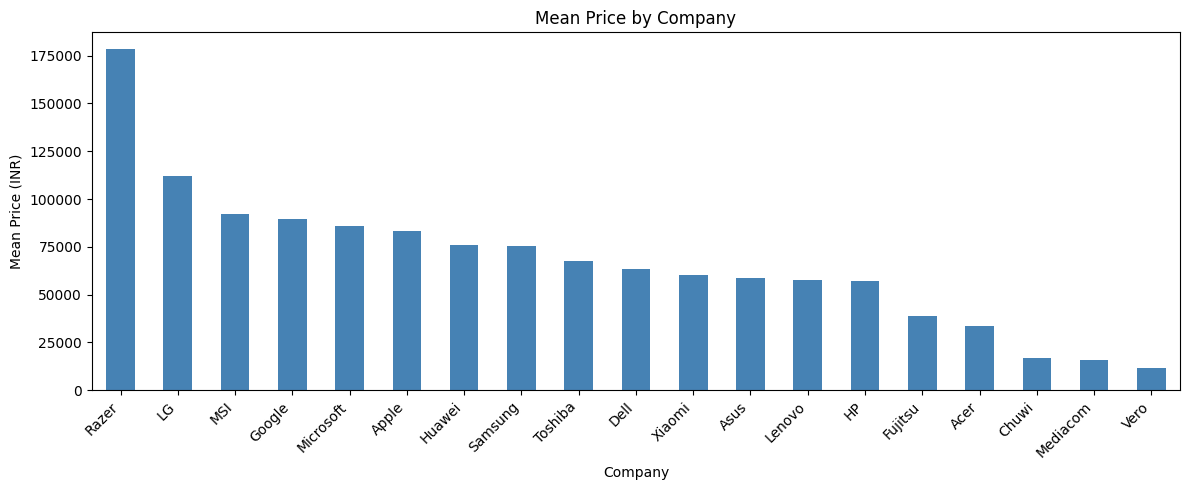

In [4]:
# Mean price by company (barplot)
plt.figure(figsize=(12, 5))
company_price = ld.groupby('Company')['Price'].mean().sort_values(ascending=False)
company_price.plot(kind='bar', color='steelblue')
plt.title("Mean Price by Company")
plt.xlabel("Company")
plt.ylabel("Mean Price (INR)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [5]:
# Target mean encoding: replace Company with mean price of that company
company_mean = ld.groupby('Company')['Price'].mean()
ld['Company_TE'] = ld['Company'].map(company_mean)

print("Encoding map (Company → mean price):")
print(company_mean.sort_values(ascending=False))

Encoding map (Company → mean price):
Company
Razer        178282.491429
LG           111834.720000
MSI           92116.226133
Google        89386.080000
Microsoft     85903.788000
Apple         83340.499886
Huawei        75870.720000
Samsung       75308.320000
Toshiba       67549.050000
Dell          63193.755782
Xiaomi        60390.882000
Asus          58830.143878
Lenovo        57882.563200
HP            56891.044222
Fujitsu       38841.120000
Acer          33394.615969
Chuwi         16745.726400
Mediacom      15717.600000
Vero          11584.404000
Name: Price, dtype: float64


In [6]:
# Verify
print(ld[['Company', 'Company_TE']].drop_duplicates().sort_values('Company_TE', ascending=False).to_string())

       Company     Company_TE
196      Razer  178282.491429
678         LG  111834.720000
58         MSI   92116.226133
437     Google   89386.080000
70   Microsoft   85903.788000
0        Apple   83340.499886
170     Huawei   75870.720000
430    Samsung   75308.320000
143    Toshiba   67549.050000
13        Dell   63193.755782
184     Xiaomi   60390.882000
8         Asus   58830.143878
18      Lenovo   57882.563200
2           HP   56891.044222
567    Fujitsu   38841.120000
5         Acer   33394.615969
30       Chuwi   16745.726400
429   Mediacom   15717.600000
191       Vero   11584.404000


In [7]:
print(f"Correlation Company_TE vs Price: {ld['Company_TE'].corr(ld['Price']):.4f}")

Correlation Company_TE vs Price: 0.4044


In [8]:
# Drop raw column
ld.drop(columns=['Company'], inplace=True)

In [9]:
ld.to_csv("laptop_data_features.csv", index=False)
print("Saved: laptop_data_features.csv")
print(f"Shape: {ld.shape}")
print(f"Columns: {list(ld.columns)}")

Saved: laptop_data_features.csv
Shape: (1303, 11)
Columns: ['TypeName', 'Inches', 'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight', 'Price', 'Company_TE']
